##Download EEG Spectrogram Dataset from Kaggle
note: may require cell to be run 2-3 times to find files in colab cache

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayushaote/eeg-spectrogram-images-for-schizophrenia-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eeg-spectrogram-images-for-schizophrenia-detection' dataset.
Path to dataset files: /kaggle/input/eeg-spectrogram-images-for-schizophrenia-detection


##Create Splits for Training, Test, and Val

In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

data_dir = "/kaggle/input/eeg-spectrogram-images-for-schizophrenia-detection/EEG_IMAGES_VGG16-20250724T160523Z-1-001/EEG_IMAGES_VGG16"
labels_df = pd.read_csv("/kaggle/input/eeg-spectrogram-images-for-schizophrenia-detection/labels.csv")
subject_df = labels_df.groupby("subject_id").first().reset_index()
split_dir = "SPLIT_IMAGES"

# Stratified splitting
train_subjects, test_subjects = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df["label"],
    random_state=42
)
val_subjects, test_subjects = train_test_split(
    test_subjects,
    test_size=0.5,
    stratify=test_subjects["label"],
    random_state=42
)

# Create a subject_id → split mapping
split_map = {}
for sid in train_subjects["subject_id"]:
    split_map[sid] = "train"
for sid in val_subjects["subject_id"]:
    split_map[sid] = "val"
for sid in test_subjects["subject_id"]:
    split_map[sid] = "test"

# Create folders
for split in ["train", "val", "test"]:
    for label in ["Control", "Patient"]:
        os.makedirs(os.path.join(split_dir, split, label), exist_ok=True)

copied = 0
for _, row in labels_df.iterrows():
    sid = row["subject_id"]
    label = row["label"]
    split = split_map.get(sid)

    #while labels_df lists .edf our images are .png
    original_filename = row["filename"]
    base_filename, _ = os.path.splitext(original_filename)
    image_filename = base_filename + ".png"

    # Construct the full source path to the image file
    src = os.path.join(data_dir, image_filename)
    dst = os.path.join(split_dir, split, label)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        copied += 1
    else:
        print(f"File not found: {src}")
        pass

print(f"Copied {copied} images into split folders at: {split_dir}")

# Set Parameters
img_size = (224, 224)
batch_size = 32

# Data generators
train_gen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, horizontal_flip=True, rotation_range=15).flow_from_directory(
    os.path.join(split_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(split_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(split_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Class weights
labels = train_gen.classes
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))

#Define Callback Parameters (prevent overfititng)
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
lr_plateau = ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=1)



Copied 1801 images into split folders at: SPLIT_IMAGES
Found 1537 images belonging to 2 classes.
Found 391 images belonging to 2 classes.
Found 281 images belonging to 2 classes.


##CNN Model and Evaluation

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

cnn_history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs= 10,
    callbacks=[early_stop, lr_plateau],
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 459ms/step - accuracy: 0.6155 - loss: 0.6619 - val_accuracy: 0.8031 - val_loss: 0.4037 - learning_rate: 0.0010
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 388ms/step - accuracy: 0.7864 - loss: 0.4718 - val_accuracy: 0.8670 - val_loss: 0.3392 - learning_rate: 0.0010
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 405ms/step - accuracy: 0.7852 - loss: 0.4652 - val_accuracy: 0.8440 - val_loss: 0.3496 - learning_rate: 0.0010
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.7997 - loss: 0.4524 - val_accuracy: 0.8338 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.7970 - loss: 0.4409
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 389ms/step - accuracy: 0.7970 - loss: 0.4410 - val_accuracy: 0.8772 - val_loss: 0.3573 - learning_rate: 0.0010
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 411ms/step - accuracy: 0.7969 - loss: 0.45

Evaluate


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6761 - loss: 0.5059
Test Accuracy: 0.8292
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step

Classification Report:
              precision    recall  f1-score   support

     Control       0.98      0.64      0.78       129
     Patient       0.77      0.99      0.86       152

    accuracy                           0.83       281
   macro avg       0.87      0.82      0.82       281
weighted avg       0.86      0.83      0.82       281



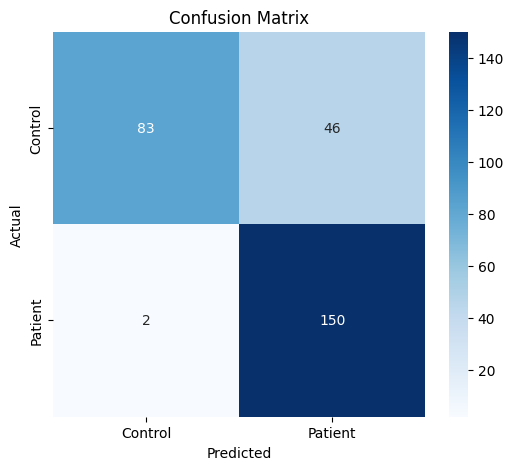

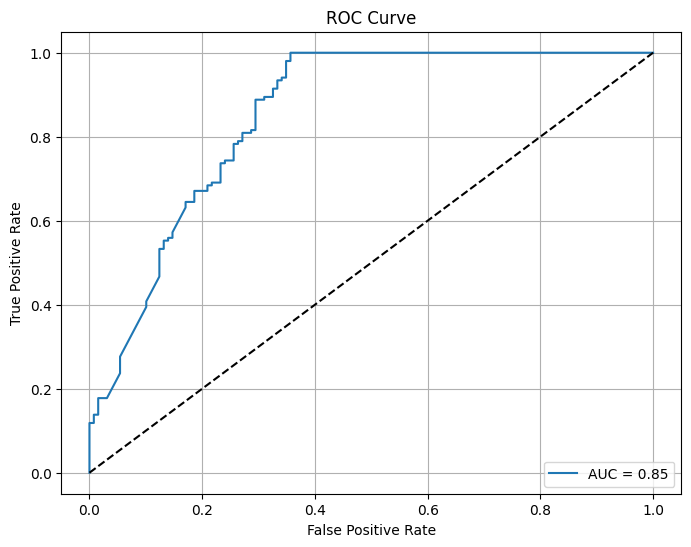

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Evaluation
loss, acc = cnn_model.evaluate(test_gen)
print(f"Test Accuracy: {acc:.4f}")

y_true = test_gen.classes
y_probabilities = cnn_model.predict(test_gen)
y_pred = np.argmax(y_probabilities, axis=1)
y_prob_positive_class = y_probabilities[:, 1]

# Classification report
print("\nClassification Report:")
class_labels = list(test_gen.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix heatmap
conf_mat = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob_positive_class)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##VGG16 Model and Evaluation

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D


base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
vgg16_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

vgg16_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg16_model.summary()

vgg16_history = vgg16_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs= 10,
    callbacks=[early_stop, lr_plateau],
    class_weight=class_weights
)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 748ms/step - accuracy: 0.5407 - loss: 0.8205 - val_accuracy: 0.7570 - val_loss: 0.5608 - learning_rate: 0.0010
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 452ms/step - accuracy: 0.6930 - loss: 0.5846 - val_accuracy: 0.7366 - val_loss: 0.4941 - learning_rate: 0.0010
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 463ms/step - accuracy: 0.7288 - loss: 0.5161 - val_accuracy: 0.7008 - val_loss: 0.4724 - learning_rate: 0.0010
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step - accuracy: 0.7316 - loss: 0.5305 - val_accuracy: 0.7033 - val_loss: 0.4681 - learning_rate: 0.0010
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 478ms/step - accuracy: 0.7344 - loss: 0.5094 - val_accuracy: 0.7442 - val_loss: 0.4602 - learning_rate: 0.0010
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 455ms/step - accuracy: 0.7432 - loss: 0.4991 - val_accuracy: 0.7366 - val_loss: 0.4576 - learning_rate: 0.0010
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 446ms/step - accuracy: 0.7488 - loss: 0.

Evaluate


9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5329 - loss: 0.6823
Test Accuracy: 0.6975
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step

Classification Report:
              precision    recall  f1-score   support

     Control       0.81      0.45      0.58       129
     Patient       0.66      0.91      0.76       152

    accuracy                           0.70       281
   macro avg       0.73      0.68      0.67       281
weighted avg       0.73      0.70      0.68       281



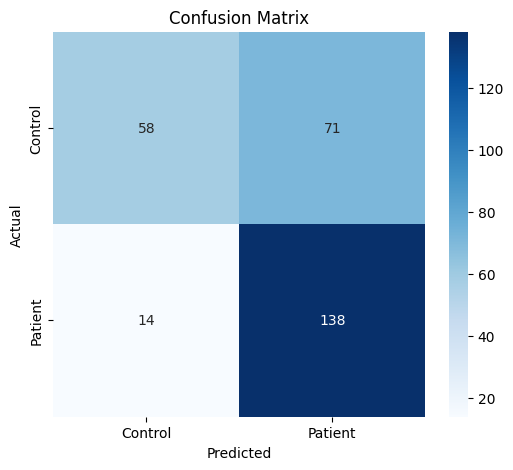

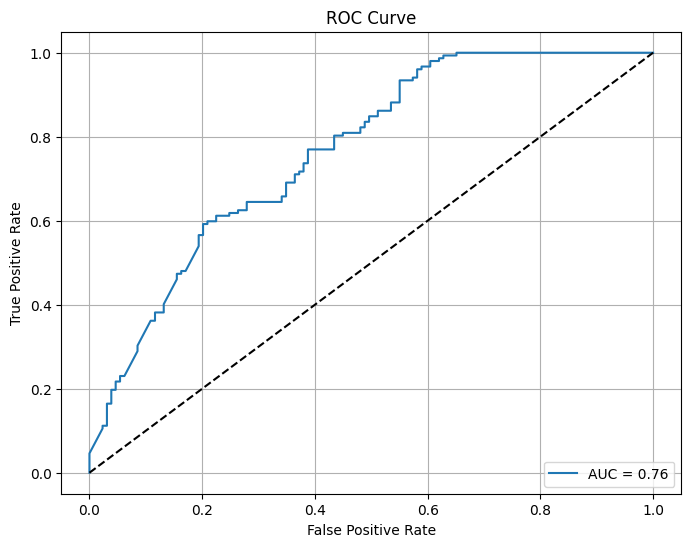

In [ ]:
# Import Necessary Libraries

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Evaluation
loss, acc = vgg16_model.evaluate(test_gen)
print(f"Test Accuracy: {acc:.4f}")

y_true = test_gen.classes
y_probabilities = vgg16_model.predict(test_gen)
y_pred = np.argmax(y_probabilities, axis=1)
y_prob_positive_class = y_probabilities[:, 1]

# Classification report
print("\nClassification Report:")
class_labels = list(test_gen.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix heatmap
conf_mat = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob_positive_class)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##Comparision of Models

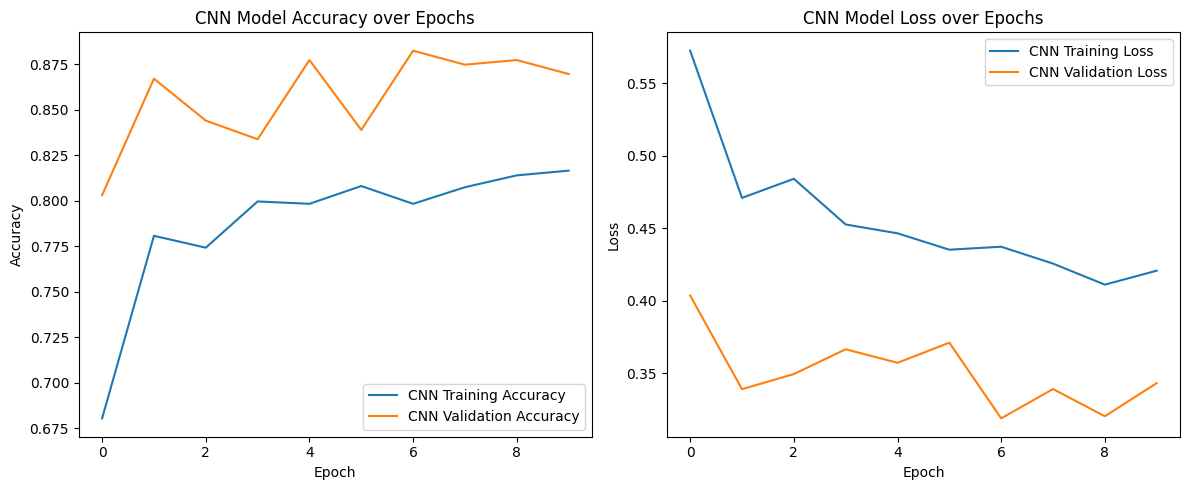

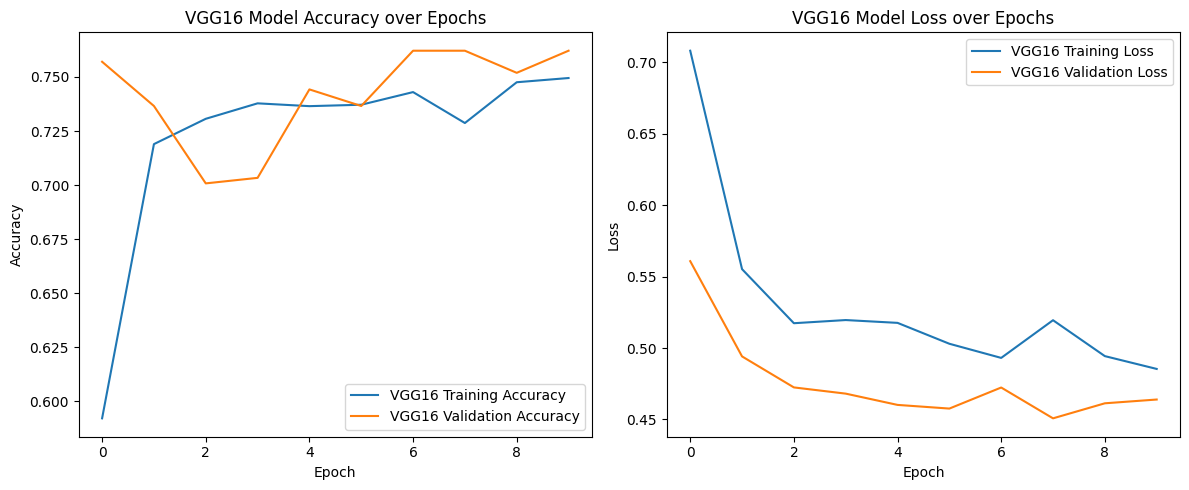

In [ ]:
import matplotlib.pyplot as plt

# Plotting CNN training history
plt.figure(figsize=(12, 5))

  # Plot CNN Accuracy

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('CNN Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

  # Plot CNN Loss - Validation & Training

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Training Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Plotting VGG16 training history
plt.figure(figsize=(12, 5))

  # Plot VGG16 Accuracy

plt.subplot(1, 2, 1)
plt.plot(vgg16_history.history['accuracy'], label='VGG16 Training Accuracy')
plt.plot(vgg16_history.history['val_accuracy'], label='VGG16 Validation Accuracy')
plt.title('VGG16 Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

  # Plot VGG16 Loss - Training & Validation

plt.subplot(1, 2, 2)
plt.plot(vgg16_history.history['loss'], label='VGG16 Training Loss')
plt.plot(vgg16_history.history['val_loss'], label='VGG16 Validation Loss')
plt.title('VGG16 Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

  # Display Plots

plt.tight_layout()
plt.show()